In [2]:
import pandas as pd

data = pd.DataFrame({
    'Math' : [70,60,40,80,30],
    'Chemistry' : [60,80,65,55,60],
    'Maths' : [70,60,40,80,30],
    'Physics' : [50,50,50,50,50],
    'General Test' : [70,70,60,60,80]
})

print(data)

   Math  Chemistry  Maths  Physics  General Test
0    70         60     70       50            70
1    60         80     60       50            70
2    40         65     40       50            60
3    80         55     80       50            60
4    30         60     30       50            80


## Variance

In [3]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0)
selected_features = selector.fit_transform(data)

In [5]:
data = pd.DataFrame(selected_features,columns=selector.get_feature_names_out())
print(data)

   Math  Chemistry  Maths  General Test
0    70         60     70            70
1    60         80     60            70
2    40         65     40            60
3    80         55     80            60
4    30         60     30            80


## Correlation

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
cor = data.corr()
cor

,Math,Chemistry,Maths,General Test
Math,1.000000,-0.150424,1.000000,-0.489932
Chemistry,-0.150424,1.000000,-0.150424,0.124274
Maths,1.000000,-0.150424,1.000000,-0.489932
General Test,-0.489932,0.124274,-0.489932,1.000000


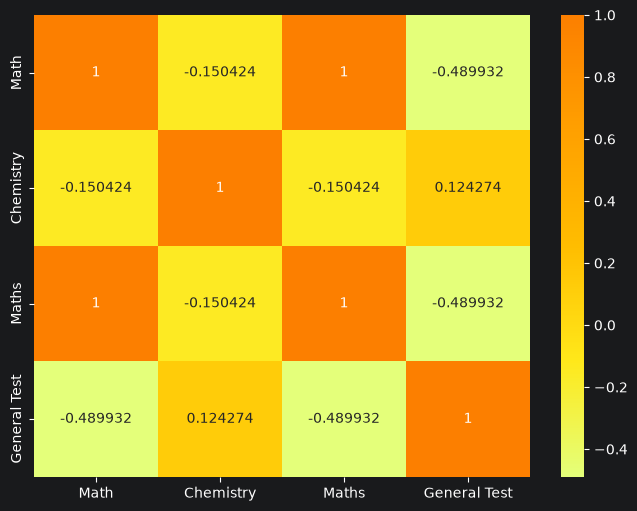

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(cor, annot=True, cmap="Wistia", fmt="g")
plt.show()

In [9]:
corr_features = set()
for i in range(len(cor.columns)):
    for j in range(i):
        if abs(cor.iloc[i,j]) > 0.9:
            colname = cor.columns[i]
            corr_features.add(colname)

In [10]:
corr_features

{'Maths'}

In [11]:
data = data.drop(corr_features,axis=1)
data

,Math,Chemistry,General Test
0,70,60,70
1,60,80,70
2,40,65,60
3,80,55,60
4,30,60,80
